# Deepfake Speech Audio Detection Full Model

## The explanations for this notebook are in the full report. This notebook is more focused on generating the figures and results.

This notebook walks through the analysis of deepfake audio detection models that are trained only using a balanced dataset including both male and female samples, grouped by speaker gender.

In [17]:
from google.colab import drive
drive.mount('/content/drive')
import librosa
import librosa.feature
import numpy as np
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import os
import seaborn as sns
import shap
from sklearn.metrics import accuracy_score
import xgboost as xgb

# define torch device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Simple Neural Network

In [4]:
# Define a simple neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(inplace=False),
            nn.Linear(128, 64),
            nn.ReLU(inplace=False),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
'''
Classification report on Basic full model on its own test set
'''

# Load the full dataset
balanced_df = pd.read_csv("/content/drive/My Drive/LING_199/DATASET-balanced.csv")

# rename 'label' to 'LABEL' if necessary
if 'label' in balanced_df.columns and 'LABEL' not in balanced_df.columns:
    balanced_df = balanced_df.rename(columns={'label': 'LABEL'})

# rename 'FAKE' as 1 and 'REAL' as 0 if necessary
if 'FAKE' in balanced_df['LABEL'].unique() and 'REAL' in balanced_df['LABEL'].unique():
    balanced_df['LABEL'] = balanced_df['LABEL'].map({'FAKE': 1, 'REAL': 0})

# Separate features and labels
X_full = balanced_df.drop(columns=['LABEL']).values
y_full = balanced_df['LABEL'].values

# Split into training and testing sets
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

# load the trained simple NN full model
full_model = torch.load('/content/drive/My Drive/LING_199/trained_models/full_models/86.42_basic_full_model.pth', weights_only=False)

# Collect all test data in a single tensor
X_test_tensor_full= torch.tensor(X_test_full, dtype=torch.float32).to(device)
with torch.no_grad():
    logits = full_model(X_test_tensor_full)
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

# Convert probabilities to predicted labels
predicted_labels = np.argmax(probabilities, axis=1)
print("\nClassification Report:")
print(classification_report(y_test_full, predicted_labels, target_names=["REAL", "FAKE"], zero_division=1))


Classification Report:
              precision    recall  f1-score   support

        REAL       0.88      0.84      0.86      1178
        FAKE       0.85      0.89      0.87      1178

    accuracy                           0.86      2356
   macro avg       0.87      0.86      0.86      2356
weighted avg       0.87      0.86      0.86      2356



Full Model Accuracy on Balanced Dataset: 0.8737


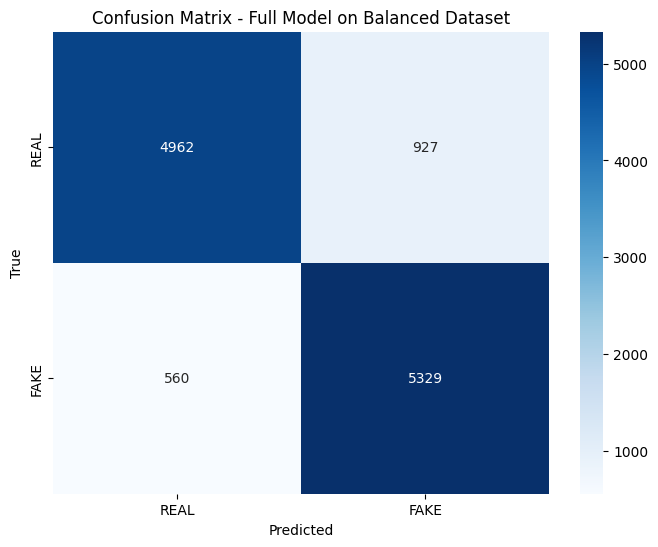

In [8]:
# confusion matrix for simple NN on full dataset

# Load the full balanced dataset
balanced_df = pd.read_csv("/content/drive/My Drive/LING_199/DATASET-balanced.csv")

# Load the full model (make sure weights_only=False)
full_model = torch.load('/content/drive/My Drive/LING_199/trained_models/full_models/86.42_basic_full_model.pth', weights_only=False)

# Ensure correct column order and drop label
feature_names = balanced_df.columns.drop('LABEL').tolist()
X_full = balanced_df[feature_names].values
y_full = balanced_df['LABEL'].values

# Map string labels to numeric
label_mapping = {'REAL': 0, 'FAKE': 1}
y_full = balanced_df['LABEL'].map(label_mapping).values

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensors
X_tensor = torch.tensor(X_full, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_full, dtype=torch.long).to(device)

# Move model to device
full_model.to(device)
full_model.eval()

# Get predictions
with torch.no_grad():
    outputs = full_model(X_tensor)
    _, predictions = torch.max(outputs, 1)

# Calculate accuracy
correct = (predictions == y_tensor).sum().item()
accuracy = correct / len(y_full)
print(f"Full Model Accuracy on Balanced Dataset: {accuracy:.4f}")

# Compute confusion matrix
cm = confusion_matrix(y_full, predictions.cpu().numpy())

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Full Model on Balanced Dataset')
plt.show()

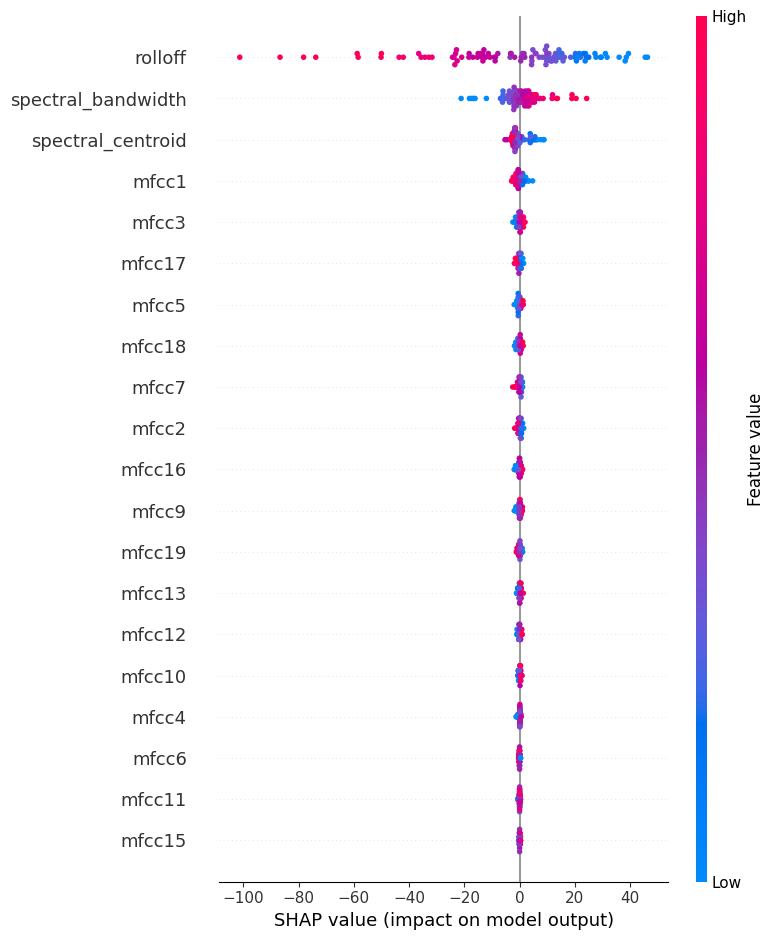

In [7]:
# use shap to visualize feature importance in the basic NN full model
import shap

# define the device, cuda if available, cpu otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load the trained simple NN female model (same training loop as male/female above)
full_model = torch.load('/content/drive/My Drive/LING_199/trained_models/full_models/86.42_basic_full_model.pth', weights_only=False)

# Convert model to evaluation mode
full_model.eval()

# prepare data for shap

# background is a small batch of training samples used to approximate
# the expected model output in SHAP. This is used to calculate baseline
# contributions
background = torch.tensor(X_train_full[:100], dtype=torch.float32).to(device)

# subset the first 100 test samples for feature explanation
X_test_tensor = torch.tensor(X_test_full[:100], dtype=torch.float32).to(device)

# Create a SHAP GradientExplainer, for PyTorch neural networks
# this explainer uses the background data to calculate baseline model behavior
explainer = shap.GradientExplainer(full_model, background)

# Get SHAP values for a subset of the test set
# shape: (samples, features, outputs) outputs = 1 for binary classification
shap_values = explainer.shap_values(X_test_tensor_full[:100])

'''
transform shap_values shape from (100, 26, 1) to (100, 26)
where 100 is the samples of the test set
and 26 is the number of features
'''
# use this for the improved complex NN model
# shap_values = shap_values.squeeze(-1)

# use this for the basic NN model
# shap_values is (100, 26, 2), select the SHAP values for class 1
shap_values = shap_values[:, :, 1]  # Now shape is (100, 26)


# extract feature names from original dataframe
feature_names = balanced_df.drop(columns=['LABEL']).columns.tolist()

# can also use this list manually
'''
feature_names = ['chroma_stft', 'rms', 'spectral_centroid', 'spectral_bandwidth',
 'rolloff', 'zero_crossing_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5',
 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13',
 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20']
 '''

# Sometimes, for binary classification with a single output,
# shap_values is a list with one element depending on the backend
if isinstance(shap_values, list):
    shap_values = shap_values[0]  # Shape: (samples, features)

# Convert to numpy if needed
if torch.is_tensor(shap_values):
    shap_values = shap_values.cpu().numpy()

# Create SHAP summary plot
shap.summary_plot(shap_values, X_test_full[:100], feature_names=feature_names, rng=42)

# Complex Neural Network

In [11]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ImprovedComplexNN(nn.Module):
    def __init__(self, input_size):
        super(ImprovedComplexNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.act3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)  # Added BatchNorm
        self.act4 = Swish()  # Swish activation function

        self.fc5 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = self.act4(x)

        x = self.fc5(x)
        return torch.sigmoid(x)  # Apply Sigmoid at the output layer


In [13]:
'''Classification report on Complex model's own test dataset
'''

# Load the dataset
df = pd.read_csv("/content/drive/My Drive/LING_199/DATASET-balanced.csv")

# Separate features and labels
X = df.drop(columns=['LABEL']).values
y = df['LABEL'].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Map string labels to numeric for BOTH y_test and predicted_labels
label_mapping = {'REAL': 0, 'FAKE': 1}
y_test = [label_mapping[label] for label in y_test] # Convert y_test to numerical labels

# define device, cuda if available, cpu otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load a previously trained model, make sure weights only is false
model = torch.load('/content/drive/My Drive/LING_199/trained_models/full_models/98.34_model.pth', weights_only=False, map_location=torch.device(device))

# Collect all test data in a single tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Get predicted probabilities
with torch.no_grad():
    probs = model(X_test_tensor).cpu().numpy().flatten()  # Shape: (N,)
    predicted_labels = (probs > 0.5).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, predicted_labels, target_names=["REAL", "FAKE"]))


Classification Report:
              precision    recall  f1-score   support

        REAL       0.97      0.98      0.98      1178
        FAKE       0.98      0.97      0.98      1178

    accuracy                           0.98      2356
   macro avg       0.98      0.98      0.98      2356
weighted avg       0.98      0.98      0.98      2356



Accuracy: 0.9787775891341256


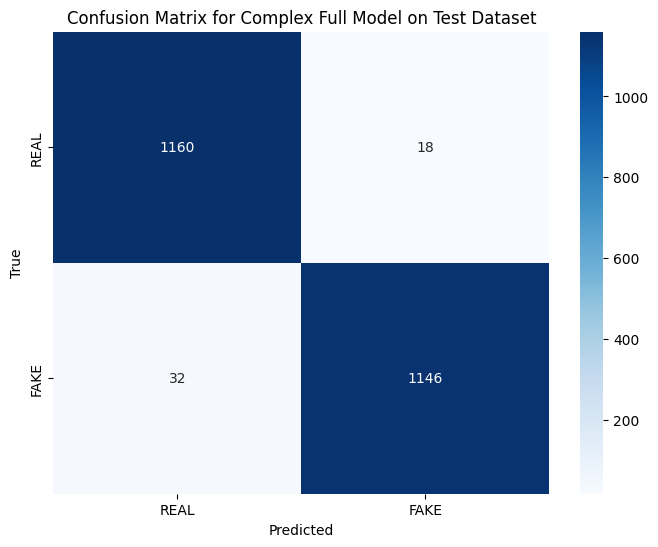

In [15]:
'''Confusion matrix of complex model on it's own test data
'''
# create a confusion matrix of complex model on full dataset's test data

# Load the dataset
df = pd.read_csv("/content/drive/My Drive/LING_199/DATASET-balanced.csv")

# Separate features and labels
X = df.drop(columns=['LABEL']).values
y = df['LABEL'].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Map string labels to numeric for BOTH y_test and predicted_labels
label_mapping = {'REAL': 0, 'FAKE': 1}
y_test = [label_mapping[label] for label in y_test] # Convert y_test to numerical labels

# define device, cuda if available, cpu otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load a previously trained model, make sure weights only is false
model = torch.load('/content/drive/My Drive/LING_199/trained_models/full_models/98.34_model.pth', weights_only=False, map_location=torch.device(device))

# Collect all test data in a single tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Get predicted probabilities
with torch.no_grad():
    probs = model(X_test_tensor).cpu().numpy().flatten()  # Shape: (N,)
    predicted_labels = (probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# print accuracy
print(f"Accuracy: {np.mean(predicted_labels == y_test)}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Complex Full Model on Test Dataset')
plt.show()

<ipython-input-16-1057ecb73883>:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names)


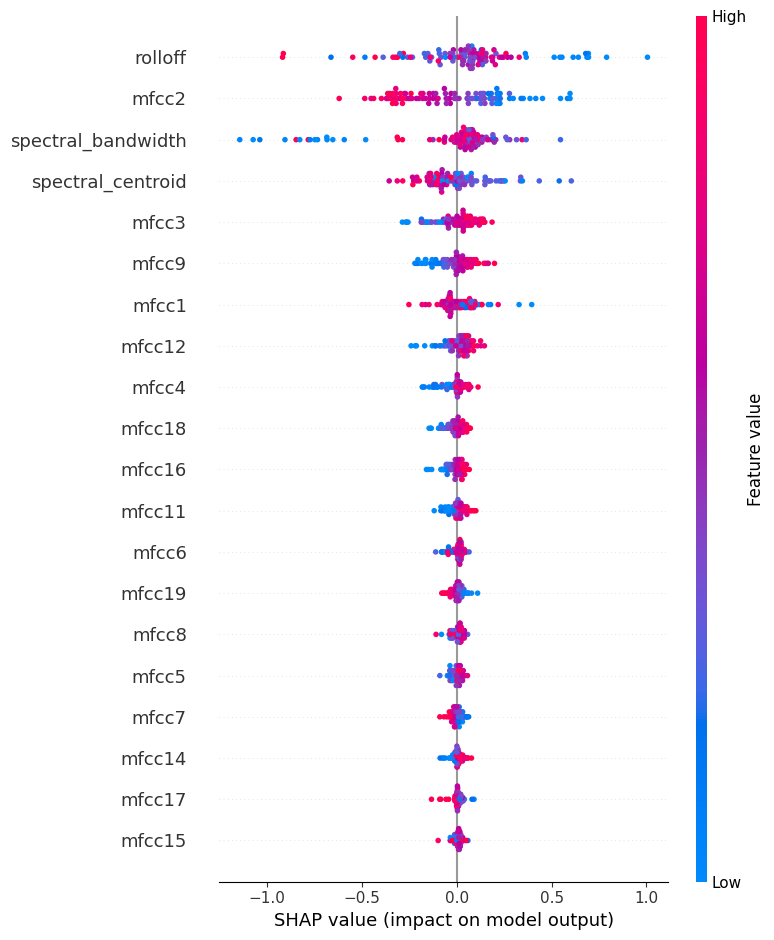

In [16]:
# use shap to visualize feature importance in the improved Complex NN model
# for the full balanced ML dataset.
# First, we take the trained model, and a small batch of training data for
# shap to compute the baseline model behavior
# Then, we define the shap explainer, and get shap values by running
# the explainer (shap's base model behavior from the small batch of train data)
# on a subset of testing samples from the test data
# Now, each feature has ranked importance, with a shap value that shows how
# important the value is for determining the class for a test sample

import shap

# Convert model to evaluation mode
model.eval()

# prepare data for shap

background = torch.tensor(X_train[:100], dtype=torch.float32).to(device)

# subset the first 100 test samples for feature explanation
X_test_tensor = torch.tensor(X_test[:100], dtype=torch.float32).to(device)

# Create a SHAP GradientExplainer, for PyTorch neural networks
# this explainer uses the background data to calculate baseline model behavior
explainer = shap.GradientExplainer(model, background)

# Get SHAP values for a subset of the test set
# shape: (samples, features, outputs) outputs = 1 for binary classification
shap_values = explainer.shap_values(X_test_tensor[:100])

# transform shap_values shape from (100, 26, 1) to (100, 26)
shap_values = shap_values.squeeze(-1)

# extract feature names from original dataframe
feature_names = df.drop(columns=['LABEL']).columns.tolist()

if isinstance(shap_values, list):
    shap_values = shap_values[0]  # Shape: (samples, features)

# Convert to numpy if needed
if torch.is_tensor(shap_values):
    shap_values = shap_values.cpu().numpy()

# Create SHAP summary plot
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names)


# Extreme Gradient Boosting

In [33]:
'''Classification report for Extreme Gradient Boosting Full Model
'''
# load balanced dataset
df = pd.read_csv("/content/drive/My Drive/LING_199/DATASET-balanced.csv")

# rename 'label' to 'LABEL' if needed
if 'label' in df.columns and 'LABEL' not in df.columns:
    df.rename(columns={'label': 'LABEL'}, inplace=True)

# convert all 'REAL' to 0 and 'FAKE' to 1 in the 'LABEL' column if REAL and FAKE are in the 'LABEL' column
if 'REAL' in df['LABEL'].values and 'FAKE' in df['LABEL'].values:
    df['LABEL'] = df['LABEL'].replace({'REAL': 0, 'FAKE': 1})

# Prepare the data
X = df.drop('LABEL', axis=1)  # Features (all columns except 'LABEL')
y = df['LABEL']               # Target variable

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,
    stratify=y        # Maintain class distribution
)

# Create DMatrix for XGBoost (optimized data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# load a previously trained model
model = xgb.Booster()
model.load_model('/content/drive/My Drive/LING_199/trained_models/full_models/98.90_xgb_full_model.json')

# Make predictions
y_pred_proba = model.predict(dtest)  # Probabilities
y_pred = (y_pred_proba > 0.5).astype(int)  # Class predictions

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

<ipython-input-33-3dbcefd33fe9>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['LABEL'] = df['LABEL'].replace({'REAL': 0, 'FAKE': 1})



Model Evaluation:
Accuracy: 0.9890

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1178
           1       0.99      0.99      0.99      1178

    accuracy                           0.99      2356
   macro avg       0.99      0.99      0.99      2356
weighted avg       0.99      0.99      0.99      2356



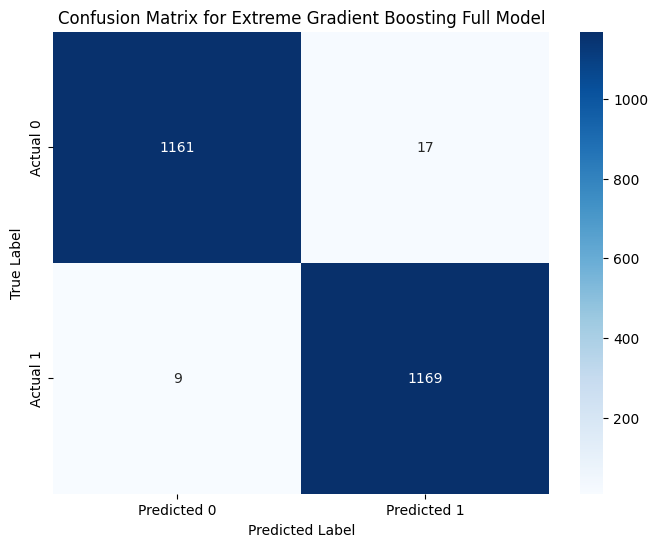

In [26]:
'''Plot confusion matrix for Extreme Gradient Boosting Full Model
'''
# load a previously trained model
model = xgb.Booster()
model.load_model('/content/drive/My Drive/LING_199/trained_models/full_models/98.90_xgb_full_model.json')

# Make predictions
y_pred_proba = model.predict(dtest)  # Probabilities
y_pred = (y_pred_proba > 0.5).astype(int)  # Class predictions

# seaborn confusion matrix helper
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])

# plot
plot_confusion_matrix(y_test, y_pred)
plt.title('Confusion Matrix for Extreme Gradient Boosting Full Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

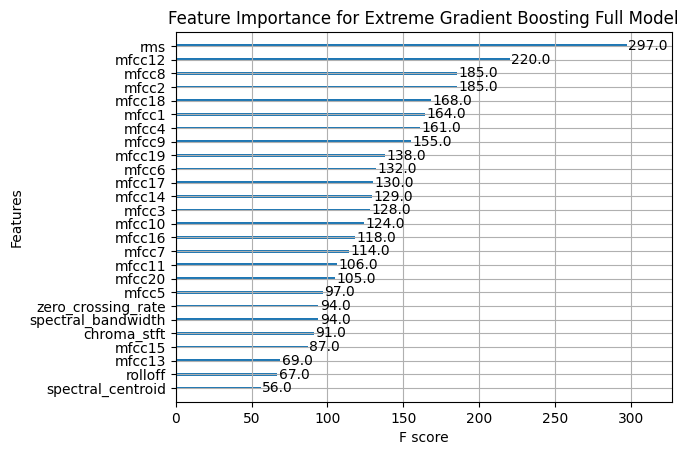

In [27]:
'''Feature Importance plot for full Extreme Gradient Boosting Model
'''
# Feature importance plot
xgb.plot_importance(model)
plt.title('Feature Importance for Extreme Gradient Boosting Full Model')
plt.show()

<ipython-input-34-1e1cbe0e731f>:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="dot")


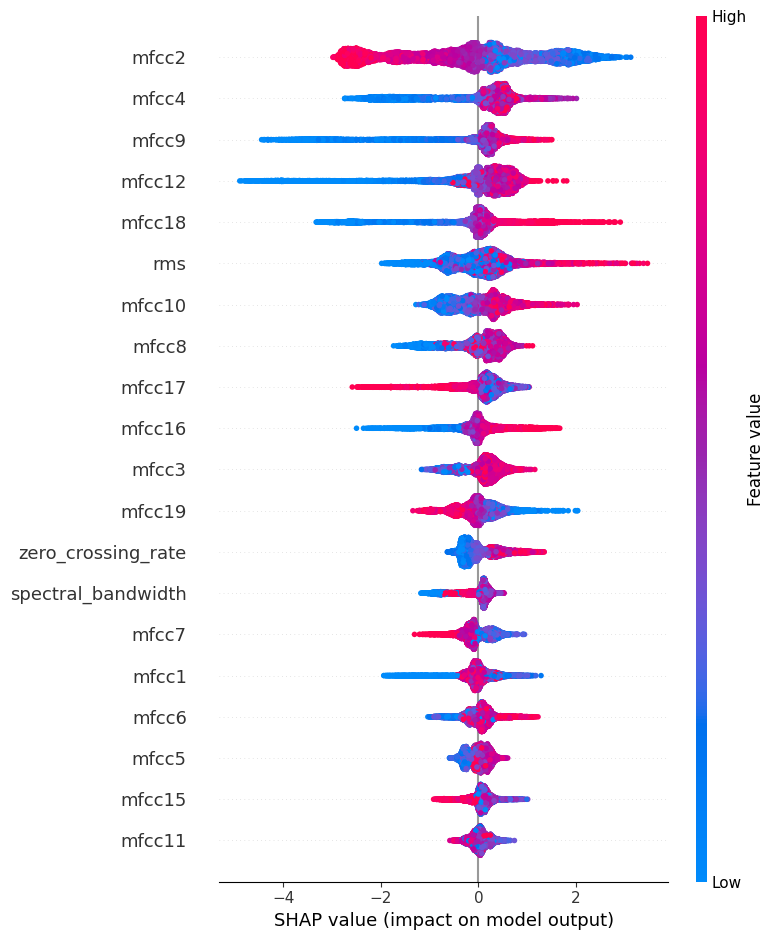

In [34]:
# Create explainer with feature names
xgb_explainer = shap.TreeExplainer(model)

# SHAP values for the test set
shap_values = xgb_explainer.shap_values(X)

# Plot beeswarm
shap.summary_plot(shap_values, X, plot_type="dot")